In [6]:
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import seaborn as sns
from scipy import signal
from scipy.signal import find_peaks
from scipy.signal import welch, find_peaks
from scipy.signal import butter, filtfilt
from scipy.stats import norm
from scipy.fft import fft
import scipy.signal as sig
import numpy as np
import warnings
warnings.filterwarnings('ignore')

In [3]:
def stock_finance(ticker='NVDA',periodo='2y'):
    stock=ticker
    df = yf.download(stock, period=periodo, interval="1d")
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)
    df['Returns'] = df['Close'].pct_change().dropna()
    df["MA_10"] = df["Close"].rolling(10).mean()
    df["MA_20"] = df["Close"].rolling(20).mean()
    df["MA_50"]=df["Close"].rolling(50).mean()
    df['MA_100']=df['Close'].rolling(100).mean()
    df["Volatility"] = df["Returns"].rolling(20).std()
    df["Cumulative_Returns"] = (1 + df["Returns"]).cumprod()
    df["Volume_Norm"] = df["Volume"] / df["Volume"].max()
    df['Stock']=stock
    df["BB_Middle"] = df["Close"].rolling(20).mean()
    df["BB_Std"] = df["Close"].rolling(20).std()
    df["BB_Upper"] = df["BB_Middle"] + 2 * df["BB_Std"]
    df["BB_Lower"] = df["BB_Middle"] - 2 * df["BB_Std"]
    return df

def compute_rsi(data, window=14):
    delta = data.diff()

    gain = (delta.where(delta > 0, 0)).rolling(window).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window).mean()

    rs = gain / loss
    rsi = 100 - (100 / (1 + rs))

    return rsi

def compute_macd(df, fast=12, slow=26, signal=9):
    ema_fast = df["Close"].ewm(span=fast, adjust=False).mean()
    ema_slow = df["Close"].ewm(span=slow, adjust=False).mean()

    macd = ema_fast - ema_slow
    signal_line = macd.ewm(span=signal, adjust=False).mean()
    hist = macd - signal_line

    return macd, signal_line, hist

In [4]:
df=stock_finance(ticker='NVDA',periodo='2y')
df["MACD"], df["MACD_Signal"], df["MACD_Hist"] = compute_macd(df)
df["RSI"] = compute_rsi(df["Close"], 14)
df["Buy_Signal"] = (df["RSI"] < 30) & (df["Close"] < df["BB_Lower"])
df["Sell_Signal"] = (df["RSI"] > 70) & (df["Close"] > df["BB_Upper"])

[*********************100%***********************]  1 of 1 completed


In [11]:
features = [
    'Close',
    'High',
    'Low',
    'Open',
    'Volume',
    'Returns',
    'MA_10',
    'MA_20',
    'MA_50',
    'MA_100',
    'Volatility',
    'Cumulative_Returns',
    'Volume_Norm',
    'BB_Middle',
    'BB_Std',
    'BB_Upper',
    'BB_Lower',
    'MACD',
    'MACD_Signal',
    'MACD_Hist',
    'RSI'
]

from sklearn.preprocessing import StandardScaler

X = df[features].dropna()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA()

# Ver cuanta información explica por cada componente
X_pca = pca.fit_transform(X_scaled)

import pandas as pd

loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f'PC{i+1}' for i in range(pca.n_components_)],
    index=features
)

loadings[['PC1', 'PC2', 'PC3']]


var_exp = pd.DataFrame({
    "PC": range(1, len(pca.explained_variance_ratio_) + 1),
    "Varianza": pca.explained_variance_ratio_,
    "Acumulada": np.cumsum(pca.explained_variance_ratio_)
})

var_exp

,PC,Varianza,Acumulada
0,1,6.024459e-01,0.602446
1,2,1.518808e-01,0.754327
2,3,7.977282e-02,0.834099
3,4,6.796790e-02,0.902067
4,5,4.406047e-02,0.946128
5,6,3.313910e-02,0.979267
6,7,1.188922e-02,0.991156
7,8,5.531363e-03,0.996688
8,9,2.361187e-03,0.999049
9,10,5.452394e-04,0.999594


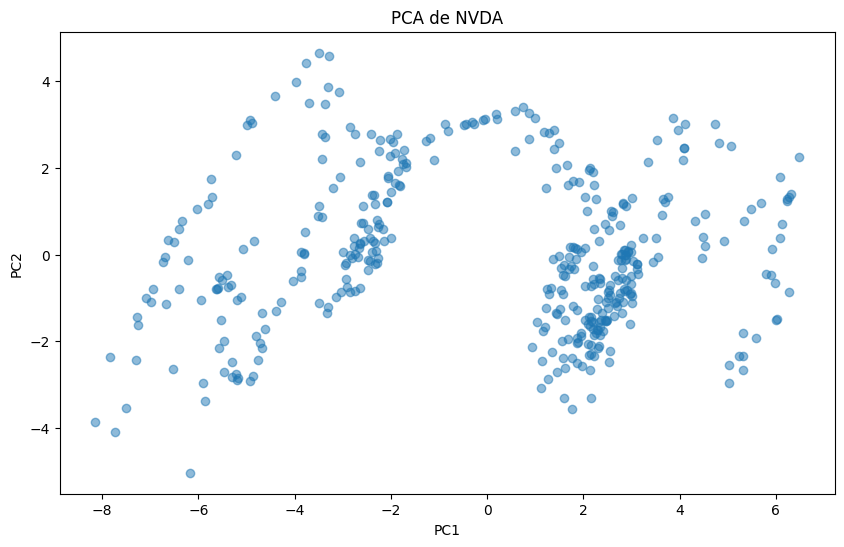

In [12]:
plt.figure(figsize=(10,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    alpha=0.5
)

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA de NVDA')
plt.show()

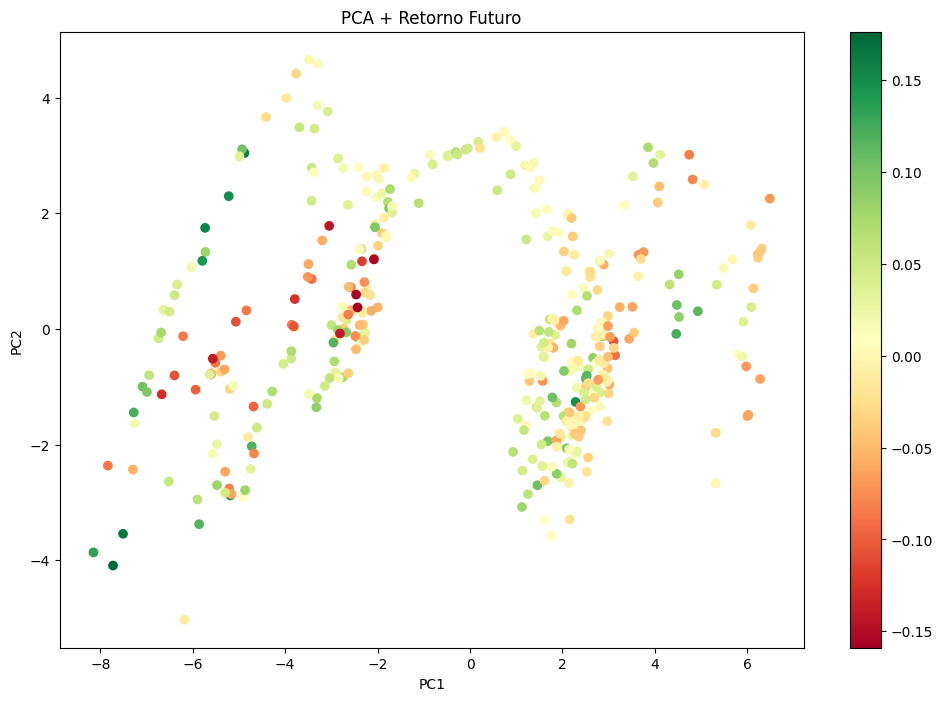

In [13]:
df['FutureReturn_5d'] = (
    df['Close'].shift(-5) / df['Close'] - 1
)

plt.figure(figsize=(12,8))

scatter = plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=df.loc[X.index, 'FutureReturn_5d'],
    cmap='RdYlGn'
)

plt.colorbar(scatter)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA + Retorno Futuro')
plt.show()

In [14]:
print(var_exp.head(10))
print(loadings[['PC1','PC2','PC3']])

   PC  Varianza  Acumulada
0   1  0.602446   0.602446
1   2  0.151881   0.754327
2   3  0.079773   0.834099
3   4  0.067968   0.902067
4   5  0.044060   0.946128
5   6  0.033139   0.979267
6   7  0.011889   0.991156
7   8  0.005531   0.996688
8   9  0.002361   0.999049
9  10  0.000545   0.999594
                         PC1       PC2       PC3
Close               0.278952  0.021310  0.051759
High                0.278649  0.009203  0.072975
Low                 0.279486  0.025937  0.037982
Open                0.278861  0.012764  0.060946
Volume             -0.154773 -0.217131  0.457177
Returns             0.002210  0.118411 -0.102249
MA_10               0.278110 -0.051727  0.060355
MA_20               0.274724 -0.111943  0.034653
MA_50               0.259062 -0.196502  0.016565
MA_100              0.233861 -0.220494  0.084638
Volatility         -0.181082 -0.149967  0.277523
Cumulative_Returns  0.278952  0.021310  0.051759
Volume_Norm        -0.154773 -0.217131  0.457177
BB_Middle        

In [15]:
print(loadings['PC1'].sort_values(key=abs, ascending=False))

Low                   0.279486
Cumulative_Returns    0.278952
Close                 0.278952
Open                  0.278861
High                  0.278649
MA_10                 0.278110
MA_20                 0.274724
BB_Middle             0.274724
BB_Upper              0.271860
BB_Lower              0.271038
MA_50                 0.259062
MA_100                0.233861
Volatility           -0.181082
Volume               -0.154773
Volume_Norm          -0.154773
MACD_Signal           0.129382
MACD                  0.120110
RSI                   0.038536
MACD_Hist            -0.005058
Returns               0.002210
BB_Std               -0.002013
Name: PC1, dtype: float64


In [16]:
print(loadings['PC2'].sort_values(key=abs, ascending=False))

RSI                   0.502371
MACD                  0.452456
MACD_Signal           0.361767
MACD_Hist             0.356866
MA_100               -0.220494
Volume_Norm          -0.217131
Volume               -0.217131
MA_50                -0.196502
Volatility           -0.149967
BB_Lower             -0.127193
Returns               0.118411
MA_20                -0.111943
BB_Middle            -0.111943
BB_Std                0.109895
BB_Upper             -0.093935
MA_10                -0.051727
Low                   0.025937
Cumulative_Returns    0.021310
Close                 0.021310
Open                  0.012764
High                  0.009203
Name: PC2, dtype: float64


In [17]:
print(loadings['PC3'].sort_values(key=abs, ascending=False))

BB_Std                0.615287
Volume_Norm           0.457177
Volume                0.457177
Volatility            0.277523
RSI                   0.150903
MACD                  0.141822
BB_Upper              0.129332
MACD_Signal           0.118557
Returns              -0.102249
MACD_Hist             0.096412
MA_100                0.084638
High                  0.072975
Open                  0.060946
MA_10                 0.060355
BB_Lower             -0.060349
Cumulative_Returns    0.051759
Close                 0.051759
Low                   0.037982
MA_20                 0.034653
BB_Middle             0.034653
MA_50                 0.016565
Name: PC3, dtype: float64


In [18]:
var_exp = pd.DataFrame({
    "Varianza": pca.explained_variance_ratio_,
    "Acumulada": pca.explained_variance_ratio_.cumsum()
})

print(var_exp.head(10))

   Varianza  Acumulada
0  0.602446   0.602446
1  0.151881   0.754327
2  0.079773   0.834099
3  0.067968   0.902067
4  0.044060   0.946128
5  0.033139   0.979267
6  0.011889   0.991156
7  0.005531   0.996688
8  0.002361   0.999049
9  0.000545   0.999594


In [19]:
print(var_exp.head(5))
print(loadings[['PC1','PC2','PC3']])

   Varianza  Acumulada
0  0.602446   0.602446
1  0.151881   0.754327
2  0.079773   0.834099
3  0.067968   0.902067
4  0.044060   0.946128
                         PC1       PC2       PC3
Close               0.278952  0.021310  0.051759
High                0.278649  0.009203  0.072975
Low                 0.279486  0.025937  0.037982
Open                0.278861  0.012764  0.060946
Volume             -0.154773 -0.217131  0.457177
Returns             0.002210  0.118411 -0.102249
MA_10               0.278110 -0.051727  0.060355
MA_20               0.274724 -0.111943  0.034653
MA_50               0.259062 -0.196502  0.016565
MA_100              0.233861 -0.220494  0.084638
Volatility         -0.181082 -0.149967  0.277523
Cumulative_Returns  0.278952  0.021310  0.051759
Volume_Norm        -0.154773 -0.217131  0.457177
BB_Middle           0.274724 -0.111943  0.034653
BB_Std             -0.002013  0.109895  0.615287
BB_Upper            0.271860 -0.093935  0.129332
BB_Lower            0.271038 

In [21]:
df_pca = pd.DataFrame(
    X_pca[:, :3],
    columns=['PC1','PC2','PC3'],
    index=X.index
)

df_pca['FutureReturn_5d'] = (
    df.loc[X.index, 'Close']
      .shift(-5)
      .div(df.loc[X.index, 'Close'])
      .sub(1)
)

df_pca.groupby(
    pd.qcut(df_pca['PC2'], 5)
)['FutureReturn_5d'].mean()

PC2
(-5.03, -1.529]     0.021163
(-1.529, -0.631]    0.007443
(-0.631, 0.174]    -0.004461
(0.174, 1.666]     -0.013596
(1.666, 4.656]      0.021241
Name: FutureReturn_5d, dtype: float64

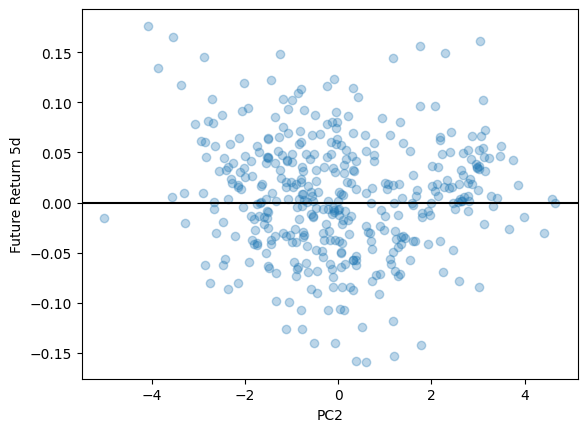

In [ ]:
plt.scatter(
    df_pca['PC2'],
    df_pca['FutureReturn_5d'],
    alpha=0.3
)

plt.axhline(0, color='black')
plt.xlabel("PC2")
plt.ylabel("Future Return 5d")
plt.show()

In [27]:
print(df_pca.groupby(
    pd.qcut(df_pca['PC3'], 5)
)['FutureReturn_5d'].mean())

PC3
(-2.533, -1.045]    0.016407
(-1.045, -0.578]    0.003590
(-0.578, 0.0313]    0.011605
(0.0313, 1.156]     0.002555
(1.156, 7.071]     -0.003054
Name: FutureReturn_5d, dtype: float64


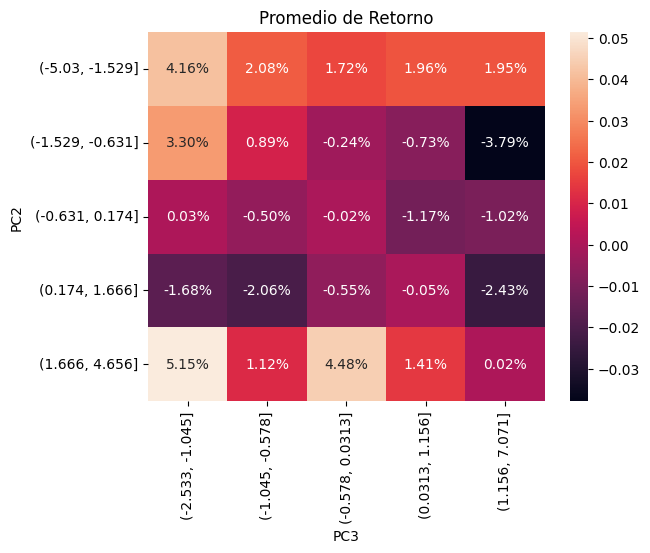

In [41]:
pivot = df_pca.pivot_table(
    values='FutureReturn_5d',
    index=pd.qcut(df_pca['PC2'],5),
    columns=pd.qcut(df_pca['PC3'],5),
    aggfunc='mean'
)

sns.heatmap(
    pivot,
    annot=True,
    fmt=".2%"
)
plt.title('Promedio de Retorno')
plt.show()

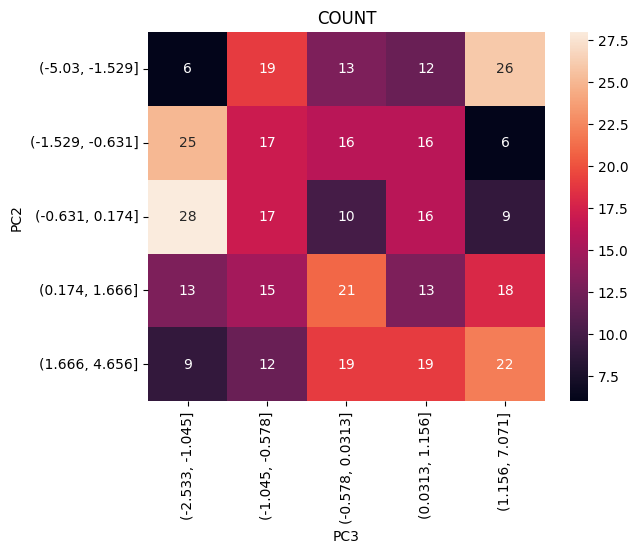

In [42]:
pivot_count = pd.pivot_table(
    df_pca,
    values='FutureReturn_5d',
    index=pd.qcut(df_pca['PC2'],5),
    columns=pd.qcut(df_pca['PC3'],5),
    aggfunc='count'
)

sns.heatmap(
    pivot_count,
    annot=True,
    fmt='d'
)
plt.title('COUNT')
plt.show()

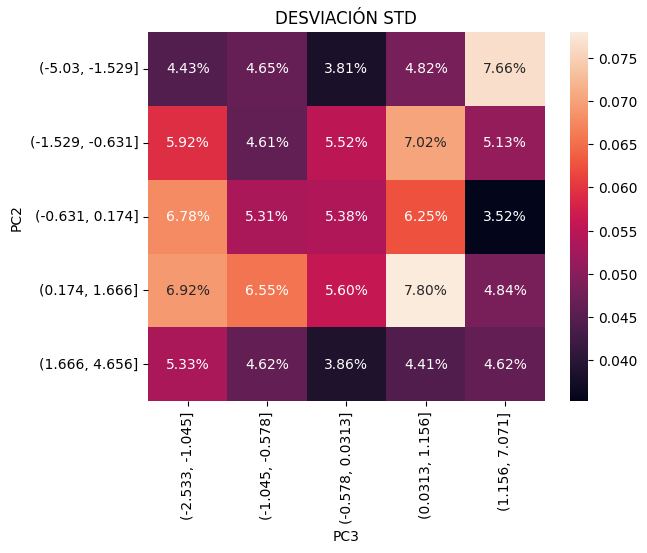

In [43]:
pivot_std = pd.pivot_table(
    df_pca,
    values='FutureReturn_5d',
    index=pd.qcut(df_pca['PC2'],5),
    columns=pd.qcut(df_pca['PC3'],5),
    aggfunc='std'
)

sns.heatmap(
    pivot_std,
    annot=True,
    fmt='.2%'
)
plt.title('DESVIACIÓN STD')
plt.show()